In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import kneighbors_graph

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.callbacks.progress import TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [2]:
def smallest_int_dtype(min_val: int, max_val: int, signed: bool = True) -> str:
    if signed:
        for t in ["int8", "int16", "int32"]:
            info = np.iinfo(t)
            if info.min <= min_val <= max_val <= info.max:
                return t
        return "int64"
    else:
        for t in ["uint8", "uint16", "uint32"]:
            if 0 <= min_val <= max_val <= np.iinfo(t).max:
                return t
        return "uint64"


def optimize_df_for_memory(df: pd.DataFrame) -> tuple:
    meta = {}
    for col in df.columns:
        s = df[col]
        unique_non_null = set(df[col].dropna().unique())
        if unique_non_null.issubset({0, 1, True, False}) and col == "Група":
            df[col] = s.astype("bool")
            meta[col] = {"stored_as": "bool", "scale": 1}
            continue
        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue
        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue
            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()
            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn, mx = int(np.nanmin(scaled)), int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                if np.dtype(int_dtype).itemsize < np.dtype("float32").itemsize:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                    continue
            df[col] = s.astype("float32")
            meta[col] = {"stored_as": "float32", "scale": 1}
    return df, meta

In [3]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [4]:
TRAIN_PATH = "../data/silver_money_calc/train.parquet"
VAL_PATH   = "../data/silver_money_calc/val.parquet"
TEST_PATH  = "../data/silver_money_calc/test.parquet"

Y_COL     = "Sum of кВт"
GROUP_COL = "EIC-код_cat"
LAT_COL   = "Широта"
LON_COL   = "Довгота"

In [5]:
MAX_ENCODER_LENGTH    = 36
MAX_PREDICTION_LENGTH = 36

BATCH_SIZE    = 64
MAX_EPOCHS    = 50
LEARNING_RATE = 3e-3

# GCN-LSTM-specific hyperparameters
GCN_HIDDEN  = 64
LSTM_HIDDEN = 64    # matches train_lstm hidden_size
LSTM_LAYERS = 2     # matches train_lstm rnn_layers
DROPOUT     = 0.1
K_NEIGHBORS = 5     # k-nearest neighbours for the station graph

In [6]:
WEATHER_FEATURES = [
    "temperature_2m", "dew_point_2m", "relative_humidity_2m",
    "precipitation", "cloud_cover_high", "wind_speed_10m", "shortwave_radiation",
]

weather_cols_to_drop = [
    "apparent_temperature", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid",
    "surface_pressure", "wind_direction_10m", "wind_gusts_10m",
    "diffuse_radiation", "direct_normal_irradiance",
]

TIME_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]
STATIC_FEATURES = [LAT_COL, LON_COL]

# Encoder sees past consumption + all context; decoder sees only known-future features
ENCODER_FEATURES = WEATHER_FEATURES + TIME_FEATURES + STATIC_FEATURES + [Y_COL]
DECODER_FEATURES = WEATHER_FEATURES + TIME_FEATURES + STATIC_FEATURES

In [7]:
GLOBAL_MIN_DT = None


def build_time_index(df: pd.DataFrame) -> pd.DataFrame:
    global GLOBAL_MIN_DT
    df["datetime"] = pd.to_datetime(df["datetime"])
    if GLOBAL_MIN_DT is None:
        GLOBAL_MIN_DT = df["datetime"].min()
    df["time_idx"] = (
        (df["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600
    ).astype(int)
    return df


def add_cyclical_features(df: pd.DataFrame) -> pd.DataFrame:
    df["datetime"] = pd.to_datetime(df["datetime"])
    h   = df["datetime"].dt.hour
    dow = df["datetime"].dt.dayofweek
    m   = df["datetime"].dt.month - 1
    df["hour_sin"]  = np.sin(2 * np.pi * h   / 24).astype("float32")
    df["hour_cos"]  = np.cos(2 * np.pi * h   / 24).astype("float32")
    df["dow_sin"]   = np.sin(2 * np.pi * dow /  7).astype("float32")
    df["dow_cos"]   = np.cos(2 * np.pi * dow /  7).astype("float32")
    df["month_sin"] = np.sin(2 * np.pi * m   / 12).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * m   / 12).astype("float32")
    return df


def load_and_prepare(path: str, has_y: bool = True) -> pd.DataFrame:
    df = pd.read_parquet(path).reset_index(drop=True)
    df = df[df["datetime"] >= "2024-06-30"].reset_index(drop=True)
    df.columns = df.columns.str.replace(".", "_", regex=False)
    df, _ = optimize_df_for_memory(df)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = build_time_index(df)
    df = add_cyclical_features(df)
    for col in df.select_dtypes("float64").columns:
        df[col] = df[col].astype("float32")
    if has_y:
        df[Y_COL] = df[Y_COL].astype("float32")
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
    df.drop(
        columns=[c for c in ["Ціна розподілу ЕЕ", "Ціна ЕЕ", "Money_spent"]
                 if c in df.columns],
        inplace=True,
    )
    df.drop(columns=[c for c in weather_cols_to_drop if c in df.columns], inplace=True)
    return df

In [8]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH)
print(f"train: {train.shape}  range: {train['datetime'].min()} → {train['datetime'].max()}")

print("Loading val   …")
val = load_and_prepare(VAL_PATH)

print("Loading test  …")
test = load_and_prepare(TEST_PATH)

print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
train: (3309985, 25)  range: 2024-06-30 00:00:00+03:00 → 2025-06-30 23:00:00+03:00
Loading val   …
Loading test  …
val : (304499, 25)
test: (304152, 25)


In [9]:
# Keep only stations present in all three splits
common = sorted(
    set(train[GROUP_COL].unique())
    & set(val[GROUP_COL].unique())
    & set(test[GROUP_COL].unique())
)
print(f"Stations in all splits: {len(common)}")

train = train[train[GROUP_COL].isin(common)].reset_index(drop=True)
val   = val  [val  [GROUP_COL].isin(common)].reset_index(drop=True)
test  = test [test [GROUP_COL].isin(common)].reset_index(drop=True)

# Static metadata: one row per station (lat/lon)
station_meta = (
    train.groupby(GROUP_COL)[[LAT_COL, LON_COL]]
    .first()
    .reindex(common)
    .reset_index()
)
station_ids = common
N_STATIONS  = len(station_ids)
print(f"N_STATIONS: {N_STATIONS}")

Stations in all splits: 397
N_STATIONS: 397


In [10]:
def make_matrix(df, feature_cols, y_col, sids):
    """Pivot df to (T, N, F) feature matrix and (T, N) target matrix."""
    all_cols = list(dict.fromkeys(feature_cols + [y_col]))
    sub = (
        df[['time_idx', GROUP_COL] + [c for c in all_cols if c in df.columns]]
        .drop_duplicates(['time_idx', GROUP_COL])
    )
    wide = sub.pivot(index='time_idx', columns=GROUP_COL, values=all_cols)
    wide = wide.ffill().fillna(0.0)

    times = wide.index.tolist()
    X = np.stack(
        [wide[col].reindex(columns=sids).values for col in feature_cols],
        axis=2,
    ).astype(np.float32)                                               # (T, N, F)
    y = wide[y_col].reindex(columns=sids).values.astype(np.float32)   # (T, N)
    return X, y, times


# Build one combined dataframe covering train + val + test
all_df = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, 'time_idx'])
)
all_df["datetime"] = pd.to_datetime(all_df["datetime"], utc=True, errors="coerce")
all_df["datetime"] = all_df["datetime"].dt.tz_convert(None)

print("Building feature matrices (may take a minute) …")
X_enc_all, y_all, times_all = make_matrix(all_df, ENCODER_FEATURES, Y_COL, station_ids)
X_dec_all, _,     _         = make_matrix(all_df, DECODER_FEATURES, Y_COL, station_ids)
print(f"X_enc_all : {X_enc_all.shape}")
print(f"X_dec_all : {X_dec_all.shape}")
print(f"y_all     : {y_all.shape}")

# Locate split boundaries
times_arr     = np.array(times_all)
train_end_pos = int(np.searchsorted(times_arr, int(train['time_idx'].max()), side='right'))
val_end_pos   = int(np.searchsorted(times_arr, int(val  ['time_idx'].max()), side='right'))
test_end_pos  = int(np.searchsorted(times_arr, int(test ['time_idx'].max()), side='right'))
print(f"train [0, {train_end_pos})  val [{train_end_pos}, {val_end_pos})  test [{val_end_pos}, {test_end_pos})")

# Feature-wise normalisation (fit on training portion only)
X_enc_tr   = X_enc_all[:train_end_pos]
X_enc_mean = X_enc_tr.mean(axis=(0, 1), keepdims=True)
X_enc_std  = X_enc_tr.std (axis=(0, 1), keepdims=True).clip(1e-8)

X_dec_tr   = X_dec_all[:train_end_pos]
X_dec_mean = X_dec_tr.mean(axis=(0, 1), keepdims=True)
X_dec_std  = X_dec_tr.std (axis=(0, 1), keepdims=True).clip(1e-8)

# Per-station target normalisation
y_tr   = y_all[:train_end_pos]
y_mean = y_tr.mean(axis=0, keepdims=True)    # (1, N)
y_std  = y_tr.std (axis=0, keepdims=True).clip(1e-8)

X_enc_norm = (X_enc_all - X_enc_mean) / X_enc_std
X_dec_norm = (X_dec_all - X_dec_mean) / X_dec_std
y_all_norm = (y_all - y_mean) / y_std

N_ENC_FEATURES = X_enc_all.shape[-1]
N_DEC_FEATURES = X_dec_all.shape[-1]
print(f"Encoder features: {N_ENC_FEATURES},  Decoder features: {N_DEC_FEATURES}")

Building feature matrices (may take a minute) …
X_enc_all : (10272, 397, 16)
X_dec_all : (10272, 397, 15)
y_all     : (10272, 397)
train [0, 8783)  val [8783, 9527)  test [9527, 10272)
Encoder features: 16,  Decoder features: 15


In [11]:
# k-NN graph from station lat/lon using haversine distance
coords_rad = np.deg2rad(station_meta[[LAT_COL, LON_COL]].values.astype(np.float64))

A = kneighbors_graph(
    coords_rad, K_NEIGHBORS,
    mode='connectivity', include_self=False, metric='haversine',
).toarray()
A = np.maximum(A, A.T).astype(np.float32)    # make symmetric

# Self-loops ensure each node retains its own features after aggregation
A_with_self = A + np.eye(N_STATIONS, dtype=np.float32)

# Row-normalise: A_norm = D^{-1} (A + I)
row_sums = A_with_self.sum(axis=1, keepdims=True).clip(1e-8)
A_norm   = (A_with_self / row_sums).astype(np.float32)

print(f"Graph: {N_STATIONS} nodes,  {int(A.sum())} directed edges")
print(f"Avg degree: {A.sum() / N_STATIONS:.1f}")

Graph: 397 nodes,  2680 directed edges
Avg degree: 6.8


In [12]:
class GCNLayer(nn.Module):
    """Graph convolution: H = ReLU(A_norm @ X @ W + b)."""

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x: torch.Tensor, adj_norm: torch.Tensor) -> torch.Tensor:
        # x: (B, N, in_features),  adj_norm: (N, N) with self-loops
        agg = torch.einsum('ij,bjk->bik', adj_norm, x)
        return F.relu(self.linear(agg))


def _gcn_over_time(x, gcn1, gcn2, adj_norm):
    """Apply two GCN layers across all time steps. x: (B, T, N, F) → (B*N, T, gcn_h)."""
    B, T, N, _ = x.shape
    x_flat = x.reshape(B * T, N, -1)                        # (B*T, N, F)
    h = gcn2(gcn1(x_flat, adj_norm), adj_norm)              # (B*T, N, gcn_h)
    h = h.reshape(B, T, N, -1)                              # (B, T, N, gcn_h)
    return h.permute(0, 2, 1, 3).reshape(B * N, T, -1)      # (B*N, T, gcn_h)


class GCNLSTM(nn.Module):
    """
    Encoder-decoder GCN-LSTM.

    Encoder: two GCN layers aggregate spatial context at each past time step,
             then an LSTM summarises the sequence into a hidden state.
    Decoder: two GCN layers aggregate spatial context for each future step
             (using known future weather/time features), then a second LSTM
             initialised from the encoder state generates predictions
             one step at a time.
    """

    def __init__(
        self,
        enc_features: int,
        dec_features: int,
        gcn_hidden:   int,
        lstm_hidden:  int,
        lstm_layers:  int,
        dropout:      float,
    ):
        super().__init__()
        lstm_drop = dropout if lstm_layers > 1 else 0.0

        self.gcn_enc1 = GCNLayer(enc_features, gcn_hidden)
        self.gcn_enc2 = GCNLayer(gcn_hidden,   gcn_hidden)
        self.encoder  = nn.LSTM(gcn_hidden, lstm_hidden, lstm_layers,
                                batch_first=True, dropout=lstm_drop)

        self.gcn_dec1 = GCNLayer(dec_features, gcn_hidden)
        self.gcn_dec2 = GCNLayer(gcn_hidden,   gcn_hidden)
        self.decoder  = nn.LSTM(gcn_hidden, lstm_hidden, lstm_layers,
                                batch_first=True, dropout=lstm_drop)

        self.dropout     = nn.Dropout(dropout)
        self.output_proj = nn.Linear(lstm_hidden, 1)

    def forward(
        self,
        x_enc:    torch.Tensor,   # (B, T_enc, N, F_enc)
        x_dec:    torch.Tensor,   # (B, T_dec, N, F_dec)
        adj_norm: torch.Tensor,   # (N, N)
    ) -> torch.Tensor:            # (B, N, T_dec)
        B = x_enc.shape[0]
        N = x_enc.shape[2]

        # --- Encoder ---
        h_enc = _gcn_over_time(x_enc, self.gcn_enc1, self.gcn_enc2, adj_norm)
        _, (h_n, c_n) = self.encoder(h_enc)   # h_n, c_n: (layers, B*N, lstm_h)

        # --- Decoder ---
        h_dec = _gcn_over_time(x_dec, self.gcn_dec1, self.gcn_dec2, adj_norm)
        dec_out, _ = self.decoder(h_dec, (h_n, c_n))  # (B*N, T_dec, lstm_h)

        out = self.output_proj(self.dropout(dec_out))  # (B*N, T_dec, 1)
        return out.reshape(B, N, -1)                   # (B, N, T_dec)


class GCNLSTMForecast(pl.LightningModule):
    def __init__(
        self,
        enc_features:  int,
        dec_features:  int,
        gcn_hidden:    int,
        lstm_hidden:   int,
        lstm_layers:   int,
        dropout:       float,
        learning_rate: float,
        adj_norm,                    # numpy array – stored as buffer
    ):
        super().__init__()
        self.save_hyperparameters(ignore=['adj_norm'])
        self.register_buffer('adj_norm', torch.tensor(adj_norm, dtype=torch.float32))
        self.model = GCNLSTM(
            enc_features, dec_features, gcn_hidden, lstm_hidden, lstm_layers, dropout,
        )

    def forward(self, x_enc: torch.Tensor, x_dec: torch.Tensor) -> torch.Tensor:
        return self.model(x_enc, x_dec, self.adj_norm)

    def _step(self, batch):
        x_enc, x_dec, y = batch    # (B,T_enc,N,F_enc), (B,T_dec,N,F_dec), (B,N,T_dec)
        return F.mse_loss(self(x_enc, x_dec), y)

    def training_step(self, batch, _):
        loss = self._step(batch)
        self.log('train_loss', loss.sqrt(), on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        loss = self._step(batch)
        self.log('val_loss', loss.sqrt(), on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.parameters(), lr=self.hparams.learning_rate, weight_decay=1e-5,
        )
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=4, factor=0.5)
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': sched, 'monitor': 'val_loss'}}

In [13]:
class GraphDataset(Dataset):
    """
    Each sample covers all N stations simultaneously.
      x_enc : (MAX_ENCODER_LENGTH, N, F_enc)  – past context including observed y
      x_dec : (MAX_PREDICTION_LENGTH, N, F_dec) – future known inputs (no y)
      y     : (N, MAX_PREDICTION_LENGTH)        – normalised target
    """

    def __init__(self, X_enc, X_dec, y_all, pred_starts, encoder_len, pred_len):
        self.X_enc  = torch.tensor(X_enc, dtype=torch.float32)
        self.X_dec  = torch.tensor(X_dec, dtype=torch.float32)
        self.y      = torch.tensor(y_all, dtype=torch.float32)
        self.starts = pred_starts
        self.EL, self.PL = encoder_len, pred_len

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        t = self.starts[i]
        return (
            self.X_enc[t - self.EL : t],      # (EL, N, F_enc)
            self.X_dec[t : t + self.PL],       # (PL, N, F_dec)
            self.y[t : t + self.PL].T,         # (N, PL)
        )


# Overlapping windows for training, non-overlapping for val/test
train_starts = list(range(MAX_ENCODER_LENGTH, train_end_pos - MAX_PREDICTION_LENGTH + 1))
val_starts   = list(range(train_end_pos,  val_end_pos  - MAX_PREDICTION_LENGTH + 1, MAX_PREDICTION_LENGTH))
test_starts  = list(range(val_end_pos,    test_end_pos - MAX_PREDICTION_LENGTH + 1, MAX_PREDICTION_LENGTH))

print(f"Training windows   : {len(train_starts)}")
print(f"Validation windows : {len(val_starts)}")
print(f"Test windows       : {len(test_starts)}")

train_ds = GraphDataset(X_enc_norm, X_dec_norm, y_all_norm, train_starts, MAX_ENCODER_LENGTH, MAX_PREDICTION_LENGTH)
val_ds   = GraphDataset(X_enc_norm, X_dec_norm, y_all_norm, val_starts,   MAX_ENCODER_LENGTH, MAX_PREDICTION_LENGTH)

NUM_WORKERS  = 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Training windows   : 8712
Validation windows : 20
Test windows       : 20

Train batches : 137
Val batches   : 1


In [14]:
gcn_lstm = GCNLSTMForecast(
    enc_features  = N_ENC_FEATURES,
    dec_features  = N_DEC_FEATURES,
    gcn_hidden    = GCN_HIDDEN,
    lstm_hidden   = LSTM_HIDDEN,
    lstm_layers   = LSTM_LAYERS,
    dropout       = DROPOUT,
    learning_rate = LEARNING_RATE,
    adj_norm      = A_norm,
)
n_params = sum(p.numel() for p in gcn_lstm.parameters() if p.requires_grad)
print(f"Number of parameters: {n_params / 1e3:.1f}k")

Number of parameters: 143.6k


In [15]:
class MetricPrinterCallback(pl.Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        m = trainer.callback_metrics
        print(
            f"[epoch={trainer.current_epoch:3d} | step={trainer.global_step:6d}]"
            f"  train_loss={float(m.get('train_loss', float('nan'))):.4f}"
            f"  val_loss={float(m.get('val_loss', float('nan'))):.4f}"
        )


early_stop = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=8, verbose=True, mode="min",
)
lr_logger  = LearningRateMonitor()
checkpoint = ModelCheckpoint(
    dirpath="checkpoints/gcn_lstm/",
    filename="gcn_lstm-{epoch:02d}-{val_loss:.4f}",
    monitor="val_loss",
    mode="min",
    save_top_k=2,
)
progress_bar = TQDMProgressBar(refresh_rate=20)
logger = TensorBoardLogger("../tb_logs", name="gcn_lstm_gas_stations")

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
print(f"Using {accelerator} accelerator")

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=1.0,
    callbacks=[early_stop, lr_logger, checkpoint, progress_bar, MetricPrinterCallback()],
    logger=logger,
    enable_progress_bar=True,
    log_every_n_steps=10,
    precision="bf16-mixed",
    val_check_interval=1.0,
    accumulate_grad_batches=4,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


Using gpu accelerator


In [16]:
trainer.fit(
    gcn_lstm,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

print(f"\nBest checkpoint : {checkpoint.best_model_path}")
print(f"Best val_loss   : {checkpoint.best_model_score:.6f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GCNLSTM │  143 K │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 143 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 143 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

[epoch= 12 | step=   455]  train_loss=0.6663  val_loss=0.9098


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 8 records. Best score: 0.842. Signaling Trainer to stop.


[epoch= 13 | step=   490]  train_loss=0.6627  val_loss=0.8790

Best checkpoint : C:\Users\Lev\Documents\GitHub\Diploma\checkpoints\gcn_lstm\gcn_lstm-epoch=05-val_loss=0.8425.ckpt
Best val_loss   : 0.842481


In [17]:
best_gcn_lstm = GCNLSTMForecast.load_from_checkpoint(
    checkpoint.best_model_path,
    adj_norm=A_norm,
    weights_only=False,
)
best_gcn_lstm.eval()
print("Loaded:", checkpoint.best_model_path)

Loaded: C:\Users\Lev\Documents\GitHub\Diploma\checkpoints\gcn_lstm\gcn_lstm-epoch=05-val_loss=0.8425.ckpt


In [18]:
def rolling_eval(model, X_enc_norm, X_dec_norm, y_raw, start_pos, end_pos,
                 encoder_len, pred_len, y_mean_arr, y_std_arr,
                 sids, device, batch_size=32):
    """
    Slide non-overlapping pred_len windows over [start_pos, end_pos).
    Encoder receives actual past observations; decoder receives known future features.
    Denormalises predictions before storing.
    """
    model.eval()
    ym = y_mean_arr.squeeze(0)[:, None]    # (N, 1)
    ys = y_std_arr .squeeze(0)[:, None]    # (N, 1)

    records = []
    windows = list(range(start_pos, end_pos - pred_len + 1, pred_len))
    X_enc_t = torch.tensor(X_enc_norm, dtype=torch.float32)
    X_dec_t = torch.tensor(X_dec_norm, dtype=torch.float32)

    for i in range(0, len(windows), batch_size):
        batch_t  = windows[i : i + batch_size]
        enc_batch = torch.stack([X_enc_t[t - encoder_len : t]  for t in batch_t]).to(device)
        dec_batch = torch.stack([X_dec_t[t : t + pred_len]     for t in batch_t]).to(device)

        with torch.no_grad():
            preds = model(enc_batch, dec_batch).cpu().numpy()   # (B, N, pred_len)

        for j, t in enumerate(batch_t):
            pred_d = preds[j] * ys + ym           # (N, pred_len) denorm
            true_w = y_raw[t : t + pred_len].T    # (N, pred_len)
            for n, sid in enumerate(sids):
                for s in range(pred_len):
                    abs_t = t + s
                    if abs_t >= end_pos:
                        break
                    records.append({
                        GROUP_COL:  sid,
                        "time_idx": abs_t,
                        "pred":     float(pred_d[n, s]),
                        Y_COL:      float(true_w[n, s]),
                    })

    return pd.DataFrame(records)


device = "cuda" if torch.cuda.is_available() else "cpu"

print("── Validation ────────────────────────────────────────────")
val_eval = rolling_eval(
    best_gcn_lstm, X_enc_norm, X_dec_norm, y_all,
    train_end_pos, val_end_pos,
    MAX_ENCODER_LENGTH, MAX_PREDICTION_LENGTH,
    y_mean, y_std, station_ids, device,
)
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Test ──────────────────────────────────────────────")
test_eval = rolling_eval(
    best_gcn_lstm, X_enc_norm, X_dec_norm, y_all,
    val_end_pos, test_end_pos,
    MAX_ENCODER_LENGTH, MAX_PREDICTION_LENGTH,
    y_mean, y_std, station_ids, device,
)
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")

── Validation ────────────────────────────────────────────
Aligned samples : 285,840
SMAPE : 0.2616
RMSE  : 10.6305
MAPE  : 28.16 %

── Test ──────────────────────────────────────────────
Aligned samples : 285,840
SMAPE : 0.2762
RMSE  : 11.4202
MAPE  : 35.13 %


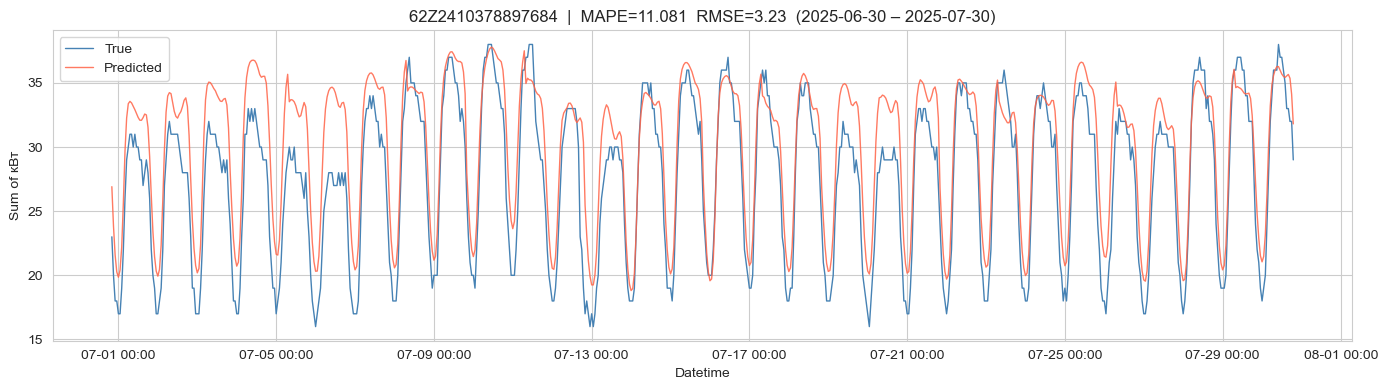

In [19]:
# Datetime lookup for plotting
dt_map = (
    all_df[['time_idx', 'datetime']]
    .drop_duplicates('time_idx')
    .set_index('time_idx')['datetime']
)


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df[eval_df[GROUP_COL] == eic_code].copy()
    df['datetime'] = pd.to_datetime(
        dt_map.reindex(df['time_idx'].values).values,
        utc=True, errors='coerce',
    ).tz_convert(None)
    df = df.sort_values('datetime')
    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df['datetime'] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df['datetime'] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df['datetime'], df[Y_COL],  label='True',      linewidth=1, color='steelblue')
    ax.plot(df['datetime'], df['pred'], label='Predicted', linewidth=1, color='tomato', alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel('Datetime')
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    fig.autofmt_xdate(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()


# Example:
plot_forecast(val_eval,  eic_code='62Z2410378897684')
# plot_forecast(test_eval, eic_code='62Z2410378897684', start_dt='2025-08-25', end_dt='2025-08-26')